In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
import os

base_path = "Daten"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gravity = pd.read_csv(os.path.join(folder_path, "Gravity.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gravity["Sensor"] = "Gravity"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gravity, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)



In [31]:
final_df

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
0,2026-03-03 10:42:47.952994800,0.251995,0.507374,0.697693,-0.160756,Accelerometer,Treppe runter,0
1,2026-03-03 10:42:47.967858000,0.266858,0.507374,0.697693,-0.160756,Accelerometer,Treppe runter,0
2,2026-03-03 10:42:47.977767700,0.276768,0.507374,0.697693,-0.160756,Accelerometer,Treppe runter,0
3,2026-03-03 10:42:47.987677400,0.286677,0.507374,0.697693,-0.160756,Accelerometer,Treppe runter,0
4,2026-03-03 10:42:47.997587200,0.296587,0.507374,0.697693,-0.160756,Accelerometer,Treppe runter,0
...,...,...,...,...,...,...,...,...
86486,2026-03-05 08:24:40.844845800,14.805846,0.254272,0.073762,0.316275,Gyroscope,Lift rauf,10
86487,2026-03-05 08:24:40.862191400,14.823191,0.369726,0.286954,0.175776,Gyroscope,Lift rauf,10
86488,2026-03-05 08:24:40.879537000,14.840537,0.359341,0.578947,0.070708,Gyroscope,Lift rauf,10
86489,2026-03-05 08:24:40.896882400,14.857882,0.314137,0.755487,0.084757,Gyroscope,Lift rauf,10


In [48]:
final_df[final_df["ID"] == 2]

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
15344,2026-03-03 12:35:10.744810000,0.189810,0.855608,-0.168431,0.098282,Accelerometer,Treppe hoch,2
15345,2026-03-03 12:35:10.759673300,0.204673,0.855608,-0.168431,0.098282,Accelerometer,Treppe hoch,2
15346,2026-03-03 12:35:10.769583400,0.214583,0.855608,-0.168431,0.098282,Accelerometer,Treppe hoch,2
15347,2026-03-03 12:35:10.779493400,0.224493,0.855608,-0.168431,0.098282,Accelerometer,Treppe hoch,2
15348,2026-03-03 12:35:10.789403400,0.234403,0.855608,-0.168431,0.098282,Accelerometer,Treppe hoch,2
...,...,...,...,...,...,...,...,...
33124,2026-03-03 12:36:09.644123100,59.089123,-0.019250,-0.186725,0.032313,Gyroscope,Treppe hoch,2
33125,2026-03-03 12:36:09.654033000,59.099033,-0.125675,-0.529513,-0.004950,Gyroscope,Treppe hoch,2
33126,2026-03-03 12:36:09.663942400,59.108942,-0.117150,-0.433675,-0.089100,Gyroscope,Treppe hoch,2
33127,2026-03-03 12:36:09.673852200,59.118852,-0.099137,-0.083600,-0.231688,Gyroscope,Treppe hoch,2


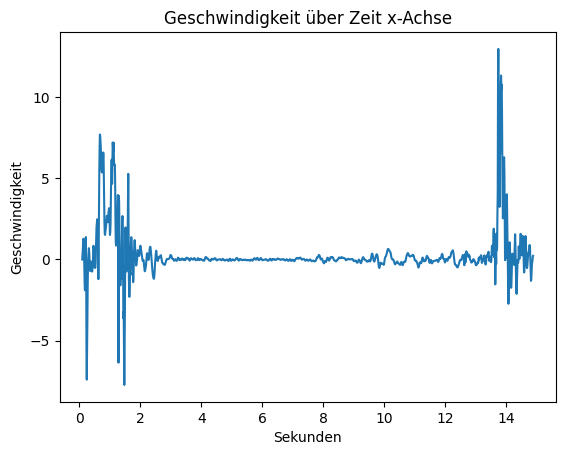

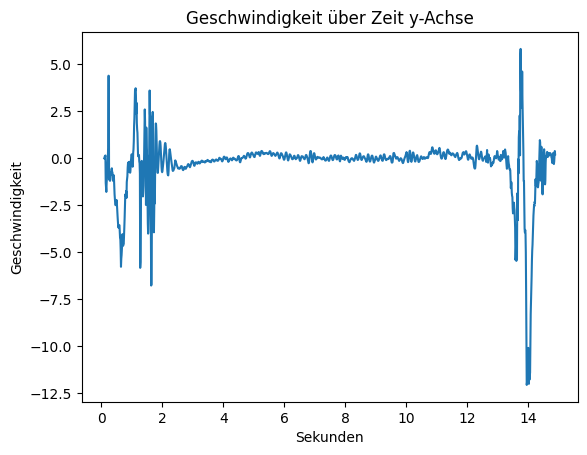

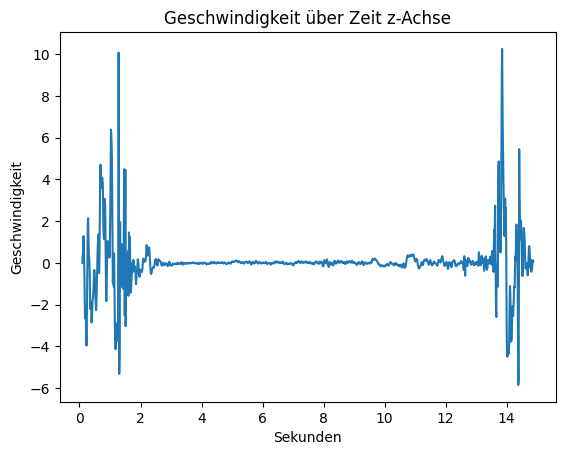

In [ ]:
speed = final_df[(final_df["Sensor"] == "Accelerometer") & (final_df['ID'] == 0)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()